# Reward Ensembles (GRPO) – Turkish MMLU Alt Küme + Baseline Deneyleri

Bu notebook'un amacı:

1) `alibayram/turkish_mmlu` veri kümesinden **bilgi ağırlıklı olmayan**, daha çok **çıkarım / mantık / yorum** gerektiren alt kümeleri seçmek  
2) En az **1000 eğitim**, **500 test** örneği oluşturmak  



In [1]:

from datasets import load_dataset, concatenate_datasets
from collections import Counter, defaultdict
import random
import re
import math


C:\Users\emirk\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reprodüksiyon (Seed) Ayarı

Notebook çıktılarının tekrarlanabilir olması için her adımda sabit seed kullanıyoruz.


In [2]:
SEED = 42
random.seed(SEED)


In [ ]:
from huggingface_hub import login
import os

login(token=os.getenv("HF_TOKEN"))

In [4]:
ds = load_dataset("alibayram/turkish_mmlu")
data = ds["train"]

print("Kolonlar:", data.column_names)
print("Toplam örnek:", len(data))


Kolonlar: ['bolum', 'konu', 'soru', 'cevap', 'aciklama', 'secenekler']
Toplam örnek: 232136


## Bölüm ve Konu Listelerini Dışa Aktarma

Bu adım, hangi bölüm/konularda ne kadar veri olduğunu görüp seçimi savunmak için faydalıdır.


In [5]:
# Bölümler
bolumler = sorted({b.strip() for b in data["bolum"] if b is not None})
print("Benzersiz bolum sayisi:", len(bolumler))

with open("bolumler.txt", "w", encoding="utf-8") as f:
    for b in bolumler:
        f.write(b + "\n")

# Konular
konular = sorted({k.strip() for k in data["konu"] if k is not None})
print("Benzersiz konu sayisi:", len(konular))

with open("konular.txt", "w", encoding="utf-8") as f:
    for k in konular:
        f.write(k + "\n")


Benzersiz bolum sayisi: 65
Benzersiz konu sayisi: 784


## Alt Küme Seçimi (KPSS / KPSS Denemeleri / YGS Denemeleri)

Burada amaç:
- Bilgi ezberi yerine
- Mantık, sözel/sayısal muhakeme, matematiksel düşünme gibi alanlara odaklanmak.

Senin daha önce kullandığın seçim mantığını aynen koruyoruz.


In [6]:
SECILI_KONULAR_KPSS_DENEME = {
    "MATEMATİK DENEMELER",
    "MATEMATİK KONU SORULARI",
    "GENEL YETENEK DENEMELER",
}

SECILI_KONULAR_KPSS = {
    "Sözel Mantık",
    "Sayısal Mantık",
    "Matematik",
    "Geometri",
}

SECILI_KONULAR_YGS = {
    "TÜRKÇE KONU SORULARI",
    "TÜRKÇE DENEMELER",
    "GEOMETRİ KONU SORULARI",
    "MATEMATİK KONU SORULARI",
}

def _not_none(x):
    return x is not None

def _norm_str(x):
    if x is None:
        return None
    return str(x).strip()


kpss_deneme = data.filter(
    lambda x: (
        _norm_str(x.get("bolum")) == "KPSS Denemeleri"
        and _norm_str(x.get("konu")) is not None and _norm_str(x.get("konu")) in SECILI_KONULAR_KPSS_DENEME
        and _not_none(x.get("cevap"))
    )
)

kpss = data.filter(
    lambda x: (
        _norm_str(x.get("bolum")) == "KPSS"
        and _norm_str(x.get("konu")) is not None and _norm_str(x.get("konu")) in SECILI_KONULAR_KPSS
        and _not_none(x.get("cevap"))
    )
)

ygs = data.filter(
    lambda x: (
        _norm_str(x.get("bolum")) == "YGS Denemeleri"
        and _norm_str(x.get("konu")) is not None and _norm_str(x.get("konu")) in SECILI_KONULAR_YGS
        and _not_none(x.get("cevap"))
    )
)

print("KPSS Denemeleri secili:", len(kpss_deneme))
print("KPSS secili:", len(kpss))
print("YGS Denemeleri secili:", len(ygs))

Filter: 100%|██████████| 232136/232136 [00:02<00:00, 94580.89 examples/s]

KPSS Denemeleri secili: 379
KPSS secili: 111
YGS Denemeleri secili: 1019


## Alt Kümenin Birleştirilmesi + Shuffle

Bu adım veri sıralamasının oluşturduğu "şans etkisini" azaltır ve tekrarlanabilir sonuç verir.


In [7]:
subset = concatenate_datasets([kpss_deneme, kpss, ygs])

print("Birlesik subset:", len(subset))
subset = subset.shuffle(seed=SEED)
print("Shuffle OK (seed=", SEED, ")")


Birlesik subset: 1509
Shuffle OK (seed= 42 )


## Cevap (0–4) Harf (A–E) Dönüşümü + Prompt Oluşturma

Veri kümesinde `cevap` alanı 0–4 aralığında:
- 0→A, 1→B, 2→C, 3→D, 4→E

Modelden beklenen çıktı: **Sadece tek harf** (A/B/C/D/E)


In [8]:
IDX_TO_LETTER = {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}
VALID_LETTERS = {"A","B","C","D","E"}

def _normalize_gt(cevap):
    if cevap is None:
        return None
    if isinstance(cevap, int):
        return IDX_TO_LETTER.get(cevap, None)
    if isinstance(cevap, str):
        c = cevap.strip().upper()
        if c in VALID_LETTERS:
            return c
    return None

def _normalize_opts(opts):
    if opts is None:
        return None

    if isinstance(opts, list):
        cleaned = [str(o).strip() for o in opts if str(o).strip()]
    elif isinstance(opts, str):
        cleaned = [o.strip() for o in opts.split("\n") if o.strip()]
    else:
        return None

    if len(cleaned) != 5:
        return None

    return cleaned

def build_prompt(ex):
    letters = ["A","B","C","D","E"]

    soru = ex.get("soru", "")
    opts = _normalize_opts(ex.get("secenekler", None))
    if opts is None:
        return None  

    options_text = "\n".join([f"{letters[i]}) {opts[i]}" for i in range(5)])

    return (
        "Soru:\n"
        f"{soru}\n\n"
        "Secenekler:\n"
        f"{options_text}\n\n"
        "Talimat: Sadece dogru secenegin harfini yaz (A, B, C, D veya E).\n"
        "Cevap:"
    )

def add_fields(ex):
    gt = _normalize_gt(ex.get("cevap", None))
    prompt = build_prompt(ex)
    return {"prompt": prompt, "gt_letter": gt}

subset = subset.map(add_fields)

subset = subset.filter(lambda x: (x["gt_letter"] is not None) and (x["prompt"] is not None))

print("GT + prompt eklendi, kalan:", len(subset))
print("GT dagilimi:", Counter(subset["gt_letter"]))


Filter: 100%|██████████| 1509/1509 [00:00<00:00, 22709.41 examples/s]


GT + prompt eklendi, kalan: 1509
GT dagilimi: Counter({'E': 320, 'C': 307, 'B': 304, 'A': 297, 'D': 281})


##  Hızlı Veri Kalite Kontrolü

Seçtiğimiz alt kümenin gerçekten "çıkarım ağırlıklı" olup olmadığını örneklerle gözle kontrol ediyoruz.


In [9]:
samples = subset.select(range(5))
for i, ex in enumerate(samples):
    print("\n---", i+1, "---")
    print("bolum:", ex["bolum"])
    print("konu :", ex["konu"])
    print("GT   :", ex["gt_letter"])
    print("prompt (kisa):", ex["prompt"][:250].replace("\n"," ") + " ...")



--- 1 ---
bolum: KPSS Denemeleri
konu : GENEL YETENEK DENEMELER
GT   : C
prompt (kisa): Soru: (I)Çağdaşlaşma(I), aydınlanma ve kültür olumlu değerleriydi yakın (II)tarihimizin(II). Ancak yaşadığımız İnternet çağında değer kaybeden bu kavramların saygın bir yeri yok (III)artık(III) toplumumuzda. Bu itibar (IV)kaybını(IV) tamamen toplulum ...

--- 2 ---
bolum: KPSS
konu : Sözel Mantık
GT   : C
prompt (kisa): Soru: Bir okulda A, B, C, D, E, F harfleriyle kodlanan altı sınıf arasında bilgi yarışması düzenlenmiştir. İlk turda iki sınıf elendikten sonra kalan dört sınıf, ikili gruplar halinde yarışıyor ve birinciler finalde mücadele ediyor. Bunlarla ilgili a ...

--- 3 ---
bolum: YGS Denemeleri
konu : TÜRKÇE KONU SORULARI
GT   : C
prompt (kisa): Soru: Aşağıdaki cümlelerin hangisinden, nesne çıkarıldığında cümlenin ögeleri 'özne ve yüklem'den oluşmuş olur?  Secenekler: A) Bir hafta içinde bu işi bırakacağım. B) Köyün büyükleri sorunları uzun uzun tartıştılar. C) Yolculardan hiçbiri böyle bir

## Alt Küme Dağılımları (Bölüm/Konu/Cevap)

- Hangi bölüm/konu ne kadar var?
- Cevap (A–E) dağılımı nasıl?


In [11]:
print("Bolum dagilimi:", Counter(subset["bolum"]))
print("\nKonu dagilimi (ilk 20):")
konu_cnt = Counter([k for k in subset["konu"] if k is not None])
for k,v in konu_cnt.most_common(20):
    print(f"{k}: {v}")

print("\nCevap (A-E) dagilimi:")
ans_cnt = Counter(subset["gt_letter"])
total = sum(ans_cnt.values())
print(ans_cnt)
print({k: round(v/total, 3) for k,v in ans_cnt.items()})


Bolum dagilimi: Counter({'YGS Denemeleri': 1019, 'KPSS Denemeleri': 379, 'KPSS': 111})

Konu dagilimi (ilk 20):
TÜRKÇE KONU SORULARI: 857
GENEL YETENEK DENEMELER: 326
TÜRKÇE DENEMELER: 120
Sözel Mantık: 98
GEOMETRİ KONU SORULARI: 39
MATEMATİK KONU SORULARI: 33
MATEMATİK DENEMELER: 23
Sayısal Mantık: 6
Matematik: 4
Geometri: 3

Cevap (A-E) dagilimi:
Counter({'E': 320, 'C': 307, 'B': 304, 'A': 297, 'D': 281})
{'C': 0.203, 'E': 0.212, 'D': 0.186, 'A': 0.197, 'B': 0.201}


## Train/Test Split – Stratified 

**Stratified split**, veriyi "dengelemek" değildir.
Sadece train ve test setlerinde A–E oranlarının benzer olmasını sağlar.

Bu, "shuffle var ama stratified yok" eleştirisini kapatır ve daha sağlam sonuç verir.


In [10]:
TRAIN_N = 1000
TEST_N  = 500
NEED = TRAIN_N + TEST_N

if len(subset) < NEED:
    raise ValueError(f"Alt kumede yeterli veri yok: {len(subset)} < {NEED}")

classes = ["A","B","C","D","E"]

# Sınıf başına indeksleri topla
idx_by_class = defaultdict(list)
for i, ex in enumerate(subset):
    idx_by_class[ex["gt_letter"]].append(i)

# Toplam sınıf sayıları
ans_cnt = {c: len(idx_by_class[c]) for c in classes}
total = sum(ans_cnt.values())

train_target = {}
test_target  = {}

for c in classes:
    train_target[c] = int(round(TRAIN_N * (ans_cnt[c] / total)))
    test_target[c]  = int(round(TEST_N  * (ans_cnt[c] / total)))

def _fix_sum(target_dict, desired_total):
    cur = sum(target_dict.values())
    while cur > desired_total:
        c = max(target_dict, key=lambda k: target_dict[k])
        if target_dict[c] > 0:
            target_dict[c] -= 1
            cur -= 1
        else:
            break
    while cur < desired_total:
        c = min(target_dict, key=lambda k: target_dict[k])
        target_dict[c] += 1
        cur += 1

_fix_sum(train_target, TRAIN_N)
_fix_sum(test_target, TEST_N)

rng = random.Random(SEED)
train_idx = []
test_idx  = []

for c in classes:
    arr = idx_by_class[c][:]
    rng.shuffle(arr)

    n_tr = train_target[c]
    n_te = test_target[c]

    if n_tr + n_te > len(arr):
        raise ValueError(f"Sinif {c} icin yeterli ornek yok: istenen {n_tr+n_te}, var {len(arr)}")

    train_idx.extend(arr[:n_tr])
    test_idx.extend(arr[n_tr:n_tr+n_te])

# Train ve test kendi içinde karışsın
rng.shuffle(train_idx)
rng.shuffle(test_idx)

train_ds = subset.select(train_idx)
test_ds  = subset.select(test_idx)

print("Train:", len(train_ds), "Test:", len(test_ds))
print("\nTrain cevap dagilimi:", Counter(train_ds["gt_letter"]))
print("Test  cevap dagilimi:", Counter(test_ds["gt_letter"]))


Train: 1000 Test: 500

Train cevap dagilimi: Counter({'E': 212, 'C': 203, 'B': 201, 'A': 197, 'D': 187})
Test  cevap dagilimi: Counter({'E': 106, 'C': 102, 'B': 101, 'A': 98, 'D': 93})


In [11]:
import os, random, re
from collections import Counter
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "ytu-ce-cosmos/turkish-gpt2-large-750m-instruct-v0.1"

# Çoklu format şablonları (SFT target)
FORMAT_TYPES = [
    "letter_only",     # A
    "answer_prefix",   # Cevap: A
    "json",            # {"answer":"A"}
]

def build_target(letter, fmt):
    if fmt == "letter_only":
        return f"{letter}"
    if fmt == "answer_prefix":
        return f"Cevap: {letter}"
    if fmt == "json":
        return f'{{"answer":"{letter}"}}'
    raise ValueError("Unknown format: " + str(fmt))


In [12]:
def add_sft_text(example):
    prompt = example["prompt"]
    gt = example["gt_letter"]

    fmt = random.choice(FORMAT_TYPES)
    target = build_target(gt, fmt)

    text = prompt + " " + target

    return {
        "format_type": fmt,
        "target_text": target,
        "text": text
    }

sft_train_raw = train_ds.map(add_sft_text)
sft_test_raw  = test_ds.map(add_sft_text)

print("SFT train sample:", sft_train_raw[0]["text"][:200], "...")
print("Format dist (train):", Counter(sft_train_raw["format_type"]))


Map: 100%|██████████| 500/500 [00:00<00:00, 5211.48 examples/s]

SFT train sample: Soru:
Onu haftalık dergilerin birinde çıkan ilginç bir hikayesiyle tanıdım. Birkaç ay sonra, yazarların vakit geçirdiği bir çay ocağında onunla yüz yüze görüşme fırsatı buldum. Kırk beş, elli yaşların ...
Format dist (train): Counter({'letter_only': 338, 'json': 335, 'answer_prefix': 327})


In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.pad_token_id


In [14]:
def tokenize_with_completion_only_labels(ex, max_len=512):
    """
    ex: {"prompt":..., "target_text":..., "text":...}
    - input_ids: prompt + target
    - labels: prompt tokenları -100, sadece target tokenları label olur
    """
    prompt = ex["prompt"]
    target = ex["target_text"]

    tok_prompt = tokenizer(prompt, add_special_tokens=False)
    tok_full   = tokenizer(prompt + " " + target, add_special_tokens=False)

    input_ids = tok_full["input_ids"][:max_len]
    attention_mask = [1] * len(input_ids)

    prompt_len = len(tok_prompt["input_ids"])
    if prompt_len > max_len:
        return {
            "input_ids": [],
            "attention_mask": [],
            "labels": [],
        }

    labels = input_ids.copy()
    for i in range(min(prompt_len, len(labels))):
        labels[i] = -100

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

tok_train = sft_train_raw.map(lambda x: tokenize_with_completion_only_labels(x, max_len=512), remove_columns=sft_train_raw.column_names)
tok_test  = sft_test_raw.map(lambda x: tokenize_with_completion_only_labels(x, max_len=512), remove_columns=sft_test_raw.column_names)

tok_train = tok_train.filter(lambda x: len(x["input_ids"]) > 0)
tok_test  = tok_test.filter(lambda x: len(x["input_ids"]) > 0)

print("Tok train:", len(tok_train), "Tok test:", len(tok_test))


Filter: 100%|██████████| 500/500 [00:00<00:00, 4620.67 examples/s]

Tok train: 1000 Tok test: 500


In [15]:
import torch
print("CUDA:", torch.cuda.is_available())
print("Device:", next(model.parameters()).device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
Device: cpu
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [20]:
from transformers import TrainingArguments, Trainer
from dataclasses import dataclass
from typing import List, Dict, Any
import torch


@dataclass
class DataCollatorForCausalLMWithLabelsPadding:
    tokenizer: Any
    label_pad_token_id: int = -100

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # input_ids + attention_mask pad
        batch = self.tokenizer.pad(
            {
                "input_ids": [f["input_ids"] for f in features],
                "attention_mask": [f["attention_mask"] for f in features],
            },
            padding=True,
            return_tensors="pt",
        )

        max_len = batch["input_ids"].shape[1]
        labels = []
        for f in features:
            lab = f["labels"]
            if len(lab) < max_len:
                lab = lab + [self.label_pad_token_id] * (max_len - len(lab))
            else:
                lab = lab[:max_len]
            labels.append(lab)

        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch


data_collator = DataCollatorForCausalLMWithLabelsPadding(tokenizer=tokenizer)


training_args = TrainingArguments(
    output_dir="./sft_out",

    num_train_epochs=1,

    per_device_train_batch_size=2,     
    gradient_accumulation_steps=8,     

    learning_rate=2e-5,
    warmup_ratio=0.03,
    weight_decay=0.0,

    logging_steps=25,
    save_steps=200,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),    
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tok_train,   
    eval_dataset=tok_test,     
    data_collator=data_collator,
)

trainer.train()

trainer.save_model("./sft_saved")
tokenizer.save_pretrained("./sft_saved")

print("SFT kaydedildi: ./sft_saved")


You're using a GPT2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
25,1.425600
50,0.730600


SFT kaydedildi: ./sft_saved


In [21]:
import torch
import random
import re
from collections import Counter
from transformers import AutoModelForCausalLM, AutoTokenizer


MODEL_PATH = "./sft_saved"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()


LETTER_RE = re.compile(r'\b([A-E])\b')

def extract_letter(text: str):
    t = text.strip()

    # JSON format
    m = re.search(r'"answer"\s*:\s*"([A-E])"', t)
    if m:
        return m.group(1)

    # "Cevap: X" format
    m = re.search(r'cevap\s*:\s*([A-E])', t, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()

    # Sadece harf
    m = LETTER_RE.search(t.upper())
    if m:
        return m.group(1)

    return None


@torch.no_grad()
def generate_one(prompt, max_new_tokens=8):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,                  
        pad_token_id=tokenizer.eos_token_id
    )

    gen = tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return gen.strip()


def eval_model_on_ds(model, ds, n=500, seed=42):
    rng = random.Random(seed)
    n = min(n, len(ds))
    idxs = [rng.randrange(0, len(ds)) for _ in range(n)]

    formats_ok = 0
    correct = 0
    dist = Counter()

    for i in idxs:
        ex = ds[i]
        prompt = ex["prompt"]
        gt = ex["gt_letter"]

        pred_text = generate_one(prompt, max_new_tokens=8)
        pred = extract_letter(pred_text)

        if pred is not None:
            formats_ok += 1
            dist[pred] += 1
            if pred == gt:
                correct += 1

    return {
        "N": n,
        "format_rate": formats_ok / n if n else 0.0,
        "accuracy": correct / n if n else 0.0,
        "dist": dist
    }


res = eval_model_on_ds(model, test_ds, n=500)

print("=== SFT TEST RESULTS ===")
print("N           :", res["N"])
print("Format rate :", round(res["format_rate"], 4))
print("Accuracy    :", round(res["accuracy"], 4))
print("Dist        :", res["dist"])


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== SFT TEST RESULTS ===
N           : 500
Format rate : 1.0
Accuracy    : 0.208
Dist        : Counter({'A': 484, 'E': 9, 'D': 7})


In [50]:
import re
import random
import torch

TRAILING_JUNK_RE = re.compile(r'[\s"\'.},]+$')

def normalize_text(text: str) -> str:
    if text is None:
        return ""
    t = text.strip()
    t = TRAILING_JUNK_RE.sub("", t)
    return t.strip()

LETTER_ANY_RE = re.compile(r"\b([A-E])\b")

def parse_pred_letter(text: str):
    t = normalize_text(text)

    m = re.search(r'"answer"\s*:\s*"([A-E])"', t)
    if m:
        return m.group(1)

    m = re.search(r"cevap\s*:\s*([A-E])", t, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()

    m = LETTER_ANY_RE.search(t.upper())
    if m:
        return m.group(1)

    return None

RE_LETTER_ONLY   = re.compile(r"^\s*([A-E])\s*$")
RE_ANSWER_PREFIX = re.compile(r'^\s*cevap\s*:\s*([A-E])\s*\.?\s*$', flags=re.IGNORECASE)
RE_JSON_FULL     = re.compile(r'^\s*\{\s*"answer"\s*:\s*"([A-E])"\s*\}\s*$', flags=re.IGNORECASE)

def check_format_ok(text: str):
    t = normalize_text(text)
    return bool(RE_LETTER_ONLY.match(t) or RE_ANSWER_PREFIX.match(t) or RE_JSON_FULL.match(t))

W_FORMAT = 0.1
W_ACC    = 0.9

def baseline_reward_single(completion_text: str, gt_letter: str) -> float:
    pred = parse_pred_letter(completion_text)
    fmt_ok = check_format_ok(completion_text)

    fmt_r = 1.0 if fmt_ok else 0.0
    acc_r = 1.0 if (pred is not None and gt_letter is not None and pred == gt_letter) else 0.0

    return W_FORMAT * fmt_r + W_ACC * acc_r

def baseline_reward_fn(prompts=None, completions=None, ground_truth=None, **kwargs):
    _dbg_once(prompts, completions, ground_truth)   # <-- SADECE BURADA

    rewards = []
    for comp, gt in zip(completions, ground_truth):
        text = comp if isinstance(comp, str) else str(comp)  # şimdilik basit
        rewards.append(baseline_reward_single(text, gt))
    return rewards


@torch.no_grad()
def generate_one(prompt, max_new_tokens=4):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=1.0,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id
    )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return gen.strip()

rng = random.Random(42)
idxs = [rng.randrange(0, len(grpo_test)) for _ in range(5)]

print("\n=== BASELINE REWARD SANITY CHECK (STRICT 3-format, short gen) ===")
for j, i in enumerate(idxs, 1):
    ex = grpo_test[i]
    prompt = ex["prompt"]
    gt = ex["ground_truth"]
    comp = generate_one(prompt, max_new_tokens=4)

    pred = parse_pred_letter(comp)
    fmt_ok = check_format_ok(comp)
    r = baseline_reward_single(comp, gt)

    print(f"[{j}] GT={gt} | raw='{comp}' | pred={pred} | fmt_ok={fmt_ok} | reward={r:.3f}")



=== BASELINE REWARD SANITY CHECK (STRICT 3-format, short gen) ===
[1] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True | reward=0.100
[2] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True | reward=0.100
[3] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True | reward=1.000
[4] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True | reward=1.000
[5] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True | reward=0.100


In [51]:
import gc
import torch
from trl import GRPOTrainer, GRPOConfig
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SFT_PATH = "./sft_saved"
tokenizer = AutoTokenizer.from_pretrained(SFT_PATH)
model = AutoModelForCausalLM.from_pretrained(SFT_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.generation_config.do_sample = True
model.generation_config.temperature = 1.0
model.generation_config.top_p = 0.95
model.generation_config.top_k = 0
model.generation_config.pad_token_id = tokenizer.eos_token_id

run_dir  = "./grpo_baseline_run"
save_dir = "./grpo_baseline_saved"

grpo_args = GRPOConfig(
    output_dir=run_dir,

    max_steps=20,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,

    num_generations=4,
    generation_batch_size=4,
    max_prompt_length=512,
    max_completion_length=4,

    learning_rate=1e-5,
    warmup_ratio=0.03,
    weight_decay=0.0,

    logging_steps=2,
    save_steps=200,
    save_total_limit=2,

    report_to="none",
)

trainer = GRPOTrainer(
    model=model,
    args=grpo_args,
    train_dataset=grpo_train,
    reward_funcs=[baseline_reward_fn],
)

trainer.train()

trainer.model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("===== TRAIN END =====")
print("Model kaydedildi:", save_dir)


<string>:192: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50257, 'pad_token_id': 0}.


DBG prompts type: <class 'list'> len: 4
DBG completions type: <class 'list'> len: 4
DBG completions[0] type: <class 'str'>
DBG completions[0] sample:  {"answer
DBG ground_truth[0]: A


Step,Training Loss
2,0.000000
4,0.000000
6,0.000000
8,0.000000
10,0.000000
12,0.000000
14,0.000000
16,0.000000
18,0.000000
20,0.000000


===== TRAIN END =====
Model kaydedildi: ./grpo_baseline_saved


In [35]:
import torch
import random
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM
import re

MODEL_PATH = "./grpo_baseline_saved"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

TRAILING_JUNK_RE = re.compile(r'[\s"\'.},]+$')

def normalize_text(text: str) -> str:
    if text is None:
        return ""
    t = text.strip()
    t = TRAILING_JUNK_RE.sub("", t)
    return t.strip()

LETTER_ANY_RE = re.compile(r"\b([A-E])\b")

def parse_pred_letter(text: str):
    t = normalize_text(text)

    m = re.search(r'"answer"\s*:\s*"([A-E])"', t)
    if m:
        return m.group(1).upper()

    m = re.search(r"cevap\s*:\s*([A-E])", t, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()

    m = LETTER_ANY_RE.search(t.upper())
    if m:
        return m.group(1)

    return None

RE_LETTER_ONLY   = re.compile(r"^\s*([A-E])\s*$")
RE_ANSWER_PREFIX = re.compile(r'^\s*cevap\s*:\s*([A-E])\s*\.?\s*$', flags=re.IGNORECASE)
RE_JSON_FULL     = re.compile(r'^\s*\{\s*"answer"\s*:\s*"([A-E])"\s*\}\s*$', flags=re.IGNORECASE)

def check_format_ok(text: str):
    t = normalize_text(text)
    return bool(RE_LETTER_ONLY.match(t) or RE_ANSWER_PREFIX.match(t) or RE_JSON_FULL.match(t))

@torch.no_grad()
def generate_one(prompt, max_new_tokens=4):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # GREEDY for evaluation
        pad_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def eval_on_ds(ds, n=500, seed=42):
    rng = random.Random(seed)
    n = min(n, len(ds))
    idxs = [rng.randrange(0, len(ds)) for _ in range(n)]

    formats = 0
    correct = 0
    dist = Counter()
    preview = []

    for k, i in enumerate(idxs):
        ex = ds[i]
        prompt = ex["prompt"]
        gt = ex["ground_truth"] if "ground_truth" in ex else ex.get("gt_letter")

        raw = generate_one(prompt, max_new_tokens=4)
        pred = parse_pred_letter(raw)
        fmt_ok = check_format_ok(raw)

        if fmt_ok:
            formats += 1
        if pred is not None:
            dist[pred] += 1
        if pred == gt:
            correct += 1

        if k < 10:
            preview.append((gt, raw, pred, fmt_ok))

    return {
        "N": n,
        "format_rate": formats / n if n else 0.0,
        "accuracy": correct / n if n else 0.0,
        "dist": dist,
        "preview": preview,
    }

res = eval_on_ds(grpo_test, n=500)

print("=== GRPO BASELINE TEST RESULTS ===")
print("N          :", res["N"])
print("Accuracy   :", round(res["accuracy"], 4))
print("Format rate:", round(res["format_rate"], 4))
print("Dist       :", res["dist"])

print("\n--- First 10 samples ---")
for j, (gt, raw, pred, fmt_ok) in enumerate(res["preview"], 1):
    print(f"[{j}] GT={gt} | raw='{raw}' | pred={pred} | fmt_ok={fmt_ok}")


=== GRPO BASELINE TEST RESULTS ===
N          : 500
Accuracy   : 0.19
Format rate: 1.0
Dist       : Counter({'E': 500})

--- First 10 samples ---
[1] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True
[2] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True
[3] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True
[4] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True
[5] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True
[6] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True
[7] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True
[8] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True
[9] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True
[10] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True


In [55]:

NUM_GENERATIONS = 4          
W_FORMAT = 0.1
W_ACC    = 0.9
LAMBDA_DIV = 0.25            
def base_reward_single(completion_text: str, gt_letter: str) -> float:
    pred = parse_pred_letter(completion_text)
    fmt_ok = check_format_ok(completion_text)

    fmt_r = 1.0 if fmt_ok else 0.0
    acc_r = 1.0 if (pred is not None and gt_letter is not None and pred == gt_letter) else 0.0
    return W_FORMAT * fmt_r + W_ACC * acc_r

def alt1_reward_fn(prompts=None, completions=None, ground_truth=None, **kwargs):
    """
    TRL/GRPO genelde completions listesini prompt başına NUM_GENERATIONS olacak şekilde döndürür
    (prompts tekrarlı gelir). Biz bu listeyi 4'lü gruplar halinde ele alıyoruz.
    """
    rewards = []
    G = NUM_GENERATIONS

    n = len(completions)
    if n % G != 0:

        for comp, gt in zip(completions, ground_truth):
            rewards.append(base_reward_single(comp, gt))
        return rewards

    for i in range(0, n, G):
        group_comps = completions[i:i+G]
        group_gts   = ground_truth[i:i+G]  

        base_rs = [base_reward_single(c, gt) for c, gt in zip(group_comps, group_gts)]

        preds = []
        for c in group_comps:
            p = parse_pred_letter(c)
            if p is not None:
                preds.append(p)
        uniq = len(set(preds))
        if len(preds) <= 1:
            div_score = 0.0
        else:
            div_score = (uniq - 1) / (len(preds) - 1)

        bonus = LAMBDA_DIV * div_score
        for br in base_rs:
            rewards.append(br + bonus)

    return rewards


In [56]:
import gc
import torch
from trl import GRPOTrainer, GRPOConfig
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SFT_PATH = "./sft_saved"
tokenizer = AutoTokenizer.from_pretrained(SFT_PATH)
model = AutoModelForCausalLM.from_pretrained(SFT_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# GRPO completion üretimi (sampling) - keşif açık
model.generation_config.do_sample = True
model.generation_config.temperature = 1.0
model.generation_config.top_p = 0.95
model.generation_config.top_k = 0
model.generation_config.pad_token_id = tokenizer.eos_token_id

run_dir  = "./grpo_alt1_div_run"
save_dir = "./grpo_alt1_div_saved"

grpo_args = GRPOConfig(
    output_dir=run_dir,

    max_steps=100,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,

    num_generations=4,
    generation_batch_size=4,
    max_prompt_length=512,
    max_completion_length=4,

    learning_rate=1e-5,
    warmup_ratio=0.03,
    weight_decay=0.0,

    logging_steps=20,
    save_steps=200,
    save_total_limit=2,

    report_to="none",
)

trainer = GRPOTrainer(
    model=model,
    args=grpo_args,
    train_dataset=grpo_train,
    reward_funcs=[alt1_reward_fn],
)

trainer.train()

trainer.model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("===== TRAIN END =====")
print("ALT-1 model kaydedildi:", save_dir)


<string>:192: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50257, 'pad_token_id': 0}.


Step,Training Loss
20,0.000000
40,0.000000
60,0.000000
80,0.000000
100,0.000000


===== TRAIN END =====
ALT-1 model kaydedildi: ./grpo_alt1_div_saved


In [57]:
import torch
import random
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM
import re

MODEL_PATH = "./grpo_alt1_div_saved"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

@torch.no_grad()
def generate_one(prompt, max_new_tokens=4):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # GREEDY EVAL
        pad_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def eval_on_ds(ds, n=500, seed=42):
    rng = random.Random(seed)
    n = min(n, len(ds))
    idxs = [rng.randrange(0, len(ds)) for _ in range(n)]

    formats = 0
    correct = 0
    dist = Counter()
    preview = []

    for k, i in enumerate(idxs):
        ex = ds[i]
        prompt = ex["prompt"]
        gt = ex["ground_truth"] if "ground_truth" in ex else ex.get("gt_letter")

        raw = generate_one(prompt, max_new_tokens=4)
        pred = parse_pred_letter(raw)
        fmt_ok = check_format_ok(raw)

        if fmt_ok:
            formats += 1
        if pred is not None:
            dist[pred] += 1
        if pred == gt:
            correct += 1

        if k < 10:
            preview.append((gt, raw, pred, fmt_ok))

    return {
        "N": n,
        "format_rate": formats / n if n else 0.0,
        "accuracy": correct / n if n else 0.0,
        "dist": dist,
        "preview": preview,
    }

res = eval_on_ds(grpo_test, n=500)

print("=== ALT-1 (DIVERSITY) TEST RESULTS ===")
print("N          :", res["N"])
print("Accuracy   :", round(res["accuracy"], 4))
print("Format rate:", round(res["format_rate"], 4))
print("Dist       :", res["dist"])

print("\n--- First 10 samples ---")
for j, (gt, raw, pred, fmt_ok) in enumerate(res["preview"], 1):
    print(f"[{j}] GT={gt} | raw='{raw}' | pred={pred} | fmt_ok={fmt_ok}")


=== ALT-1 (DIVERSITY) TEST RESULTS ===
N          : 500
Accuracy   : 0.22
Format rate: 1.0
Dist       : Counter({'C': 500})

--- First 10 samples ---
[1] GT=B | raw='Cevap: C"' | pred=C | fmt_ok=True
[2] GT=A | raw='Cevap: C"' | pred=C | fmt_ok=True
[3] GT=E | raw='Cevap: C"' | pred=C | fmt_ok=True
[4] GT=E | raw='Cevap: C"' | pred=C | fmt_ok=True
[5] GT=C | raw='Cevap: C"' | pred=C | fmt_ok=True
[6] GT=D | raw='Cevap: C"' | pred=C | fmt_ok=True
[7] GT=B | raw='Cevap: C"' | pred=C | fmt_ok=True
[8] GT=C | raw='Cevap: C"' | pred=C | fmt_ok=True
[9] GT=A | raw='Cevap: C"' | pred=C | fmt_ok=True
[10] GT=D | raw='Cevap: C"' | pred=C | fmt_ok=True


In [39]:
import math

NUM_GENERATIONS = 4      
W_FORMAT = 0.1
W_ACC    = 0.9
LAMBDA_ENT = 0.25        

def base_reward_single(completion_text: str, gt_letter: str) -> float:
    pred = parse_pred_letter(completion_text)
    fmt_ok = check_format_ok(completion_text)

    fmt_r = 1.0 if fmt_ok else 0.0
    acc_r = 1.0 if (pred is not None and gt_letter is not None and pred == gt_letter) else 0.0
    return W_FORMAT * fmt_r + W_ACC * acc_r

def _entropy_normalized(counts_dict, base=5):
    
    total = sum(counts_dict.values())
    if total <= 1:
        return 0.0

    H = 0.0
    for c, cnt in counts_dict.items():
        if cnt <= 0:
            continue
        p = cnt / total
        H -= p * math.log(p + 1e-12)

    return H / math.log(base)

def alt2_reward_fn(prompts=None, completions=None, ground_truth=None, **kwargs):

    rewards = []
    G = NUM_GENERATIONS

    n = len(completions)
    if n % G != 0:
        
        for comp, gt in zip(completions, ground_truth):
            rewards.append(base_reward_single(comp, gt))
        return rewards

    for i in range(0, n, G):
        group_comps = completions[i:i+G]
        group_gts   = ground_truth[i:i+G]

        base_rs = [base_reward_single(c, gt) for c, gt in zip(group_comps, group_gts)]

        
        counts = {}
        for c in group_comps:
            p = parse_pred_letter(c)
            if p is None:
                continue
            counts[p] = counts.get(p, 0) + 1

        ent = _entropy_normalized(counts, base=5)  
        bonus = LAMBDA_ENT * ent

        for br in base_rs:
            rewards.append(br + bonus)

    return rewards


In [40]:
import gc
import torch
from trl import GRPOTrainer, GRPOConfig
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SFT_PATH = "./sft_saved"
tokenizer = AutoTokenizer.from_pretrained(SFT_PATH)
model = AutoModelForCausalLM.from_pretrained(SFT_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.generation_config.do_sample = True
model.generation_config.temperature = 1.0
model.generation_config.top_p = 0.95
model.generation_config.top_k = 0
model.generation_config.pad_token_id = tokenizer.eos_token_id

run_dir  = "./grpo_alt2_entropy_run"
save_dir = "./grpo_alt2_entropy_saved"

grpo_args = GRPOConfig(
    output_dir=run_dir,

    max_steps=200,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,

    num_generations=4,
    generation_batch_size=4,
    max_prompt_length=512,
    max_completion_length=4,

    learning_rate=1e-5,
    warmup_ratio=0.03,
    weight_decay=0.0,

    logging_steps=20,
    save_steps=200,
    save_total_limit=2,

    report_to="none",
)

trainer = GRPOTrainer(
    model=model,
    args=grpo_args,
    train_dataset=grpo_train,
    reward_funcs=[alt2_reward_fn],
)

trainer.train()

trainer.model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("===== TRAIN END =====")
print("ALT-2 model kaydedildi:", save_dir)


<string>:192: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50257, 'pad_token_id': 0}.


Step,Training Loss
20,-0.000000
40,0.000000
60,0.000000
80,0.000000
100,0.000000
120,0.000000
140,0.000000
160,0.000000
180,0.000000
200,0.000000


===== TRAIN END =====
ALT-2 model kaydedildi: ./grpo_alt2_entropy_saved


In [41]:
import torch
import random
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_PATH = "./grpo_alt2_entropy_saved"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

@torch.no_grad()
def generate_one(prompt, max_new_tokens=4):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # GREEDY EVAL
        pad_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def eval_on_ds(ds, n=500, seed=42):
    rng = random.Random(seed)
    n = min(n, len(ds))
    idxs = [rng.randrange(0, len(ds)) for _ in range(n)]

    formats = 0
    correct = 0
    dist = Counter()
    preview = []

    for k, i in enumerate(idxs):
        ex = ds[i]
        prompt = ex["prompt"]
        gt = ex["ground_truth"] if "ground_truth" in ex else ex.get("gt_letter")

        raw = generate_one(prompt, max_new_tokens=4)
        pred = parse_pred_letter(raw)
        fmt_ok = check_format_ok(raw)

        if fmt_ok:
            formats += 1
        if pred is not None:
            dist[pred] += 1
        if pred == gt:
            correct += 1

        if k < 10:
            preview.append((gt, raw, pred, fmt_ok))

    return {
        "N": n,
        "format_rate": formats / n if n else 0.0,
        "accuracy": correct / n if n else 0.0,
        "dist": dist,
        "preview": preview,
    }

res = eval_on_ds(grpo_test, n=500)

print("=== ALT-2 (ENTROPY) TEST RESULTS ===")
print("N          :", res["N"])
print("Accuracy   :", round(res["accuracy"], 4))
print("Format rate:", round(res["format_rate"], 4))
print("Dist       :", res["dist"])

print("\n--- First 10 samples ---")
for j, (gt, raw, pred, fmt_ok) in enumerate(res["preview"], 1):
    print(f"[{j}] GT={gt} | raw='{raw}' | pred={pred} | fmt_ok={fmt_ok}")


=== ALT-2 (ENTROPY) TEST RESULTS ===
N          : 500
Accuracy   : 0.19
Format rate: 1.0
Dist       : Counter({'E': 500})

--- First 10 samples ---
[1] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True
[2] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True
[3] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True
[4] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True
[5] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True
[6] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True
[7] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True
[8] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True
[9] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True
[10] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True


In [42]:

NUM_GENERATIONS = 4      
W_FORMAT = 0.1
W_ACC    = 0.9
LAMBDA_FDIV = 0.25       

def base_reward_single(completion_text: str, gt_letter: str) -> float:
    pred = parse_pred_letter(completion_text)
    fmt_ok = check_format_ok(completion_text)

    fmt_r = 1.0 if fmt_ok else 0.0
    acc_r = 1.0 if (pred is not None and gt_letter is not None and pred == gt_letter) else 0.0
    return W_FORMAT * fmt_r + W_ACC * acc_r

def detect_format_type(text: str) -> str:
    
    t = normalize_text(text)

    if RE_LETTER_ONLY.match(t):
        return "letter_only"
    if RE_ANSWER_PREFIX.match(t):
        return "answer_prefix"
    if RE_JSON_FULL.match(t):
        return "json"
    return "other"

def alt3_reward_fn(prompts=None, completions=None, ground_truth=None, **kwargs):
    rewards = []
    G = NUM_GENERATIONS

    n = len(completions)
    if n % G != 0:
        for comp, gt in zip(completions, ground_truth):
            rewards.append(base_reward_single(comp, gt))
        return rewards

    for i in range(0, n, G):
        group_comps = completions[i:i+G]
        group_gts   = ground_truth[i:i+G]

        base_rs = [base_reward_single(c, gt) for c, gt in zip(group_comps, group_gts)]

        ftypes = []
        for c in group_comps:
            ft = detect_format_type(c)
            if ft in ("letter_only", "answer_prefix", "json"):
                ftypes.append(ft)

        uniq = len(set(ftypes))
        if len(ftypes) <= 1:
            fdiv = 0.0
        else:
            
            denom = (min(G, 3) - 1)
            if denom <= 0:
                fdiv = 0.0
            else:
                fdiv = (uniq - 1) / denom
                if fdiv < 0.0:
                    fdiv = 0.0
                if fdiv > 1.0:
                    fdiv = 1.0

        bonus = LAMBDA_FDIV * fdiv
        for br in base_rs:
            rewards.append(br + bonus)

    return rewards


In [43]:
import gc
import torch
from trl import GRPOTrainer, GRPOConfig
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SFT_PATH = "./sft_saved"
tokenizer = AutoTokenizer.from_pretrained(SFT_PATH)
model = AutoModelForCausalLM.from_pretrained(SFT_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


model.generation_config.do_sample = True
model.generation_config.temperature = 1.0
model.generation_config.top_p = 0.95
model.generation_config.top_k = 0
model.generation_config.pad_token_id = tokenizer.eos_token_id

run_dir  = "./grpo_alt3_formatdiv_run"
save_dir = "./grpo_alt3_formatdiv_saved"

grpo_args = GRPOConfig(
    output_dir=run_dir,

    max_steps=200,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,

    num_generations=4,
    generation_batch_size=4,
    max_prompt_length=512,
    max_completion_length=4,

    learning_rate=1e-5,
    warmup_ratio=0.03,
    weight_decay=0.0,

    logging_steps=20,
    save_steps=200,
    save_total_limit=2,

    report_to="none",
)

trainer = GRPOTrainer(
    model=model,
    args=grpo_args,
    train_dataset=grpo_train,
    reward_funcs=[alt3_reward_fn],
)

trainer.train()

trainer.model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("===== TRAIN END =====")
print("ALT-3 model kaydedildi:", save_dir)


<string>:192: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50257, 'pad_token_id': 0}.


Step,Training Loss
20,0.000000
40,0.000000
60,0.000000
80,0.000000
100,0.000000
120,0.000000
140,0.000000
160,0.000000
180,0.000000
200,0.000000


===== TRAIN END =====
ALT-3 model kaydedildi: ./grpo_alt3_formatdiv_saved


In [44]:
import torch
import random
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_PATH = "./grpo_alt3_formatdiv_saved"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

@torch.no_grad()
def generate_one(prompt, max_new_tokens=4):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # GREEDY EVAL
        pad_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def eval_on_ds(ds, n=500, seed=42):
    rng = random.Random(seed)
    n = min(n, len(ds))
    idxs = [rng.randrange(0, len(ds)) for _ in range(n)]

    formats_ok = 0
    correct = 0
    dist = Counter()
    fmt_type_dist = Counter()
    preview = []

    for k, i in enumerate(idxs):
        ex = ds[i]
        prompt = ex["prompt"]
        gt = ex["ground_truth"] if "ground_truth" in ex else ex.get("gt_letter")

        raw = generate_one(prompt, max_new_tokens=4)
        pred = parse_pred_letter(raw)
        fmt_ok = check_format_ok(raw)

        if fmt_ok:
            formats_ok += 1

        
        ft = detect_format_type(raw)
        fmt_type_dist[ft] += 1

        if pred is not None:
            dist[pred] += 1
        if pred == gt:
            correct += 1

        if k < 10:
            preview.append((gt, raw, pred, fmt_ok, ft))

    return {
        "N": n,
        "format_rate": formats_ok / n if n else 0.0,
        "accuracy": correct / n if n else 0.0,
        "dist": dist,
        "fmt_type_dist": fmt_type_dist,
        "preview": preview,
    }

res = eval_on_ds(grpo_test, n=500)

print("=== ALT-3 (FORMAT-DIVERSITY) TEST RESULTS ===")
print("N          :", res["N"])
print("Accuracy   :", round(res["accuracy"], 4))
print("Format rate:", round(res["format_rate"], 4))
print("Dist       :", res["dist"])
print("Format type dist:", res["fmt_type_dist"])

print("\n--- First 10 samples ---")
for j, (gt, raw, pred, fmt_ok, ft) in enumerate(res["preview"], 1):
    print(f"[{j}] GT={gt} | raw='{raw}' | pred={pred} | fmt_ok={fmt_ok} | fmt_type={ft}")


=== ALT-3 (FORMAT-DIVERSITY) TEST RESULTS ===
N          : 500
Accuracy   : 0.19
Format rate: 1.0
Dist       : Counter({'E': 500})
Format type dist: Counter({'answer_prefix': 500})

--- First 10 samples ---
[1] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[2] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[3] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[4] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[5] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[6] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[7] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[8] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[9] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix
[10] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True | fmt_type=answer_prefix


In [45]:

NUM_GENERATIONS = 4      
W_FORMAT = 0.1
W_ACC    = 0.9
LAMBDA_PEN = 0.30        

def base_reward_single(completion_text: str, gt_letter: str) -> float:
    pred = parse_pred_letter(completion_text)
    fmt_ok = check_format_ok(completion_text)

    fmt_r = 1.0 if fmt_ok else 0.0
    acc_r = 1.0 if (pred is not None and gt_letter is not None and pred == gt_letter) else 0.0
    return W_FORMAT * fmt_r + W_ACC * acc_r

def alt4_reward_fn(prompts=None, completions=None, ground_truth=None, **kwargs):
    rewards = []
    G = NUM_GENERATIONS

    n = len(completions)
    if n % G != 0:
        
        for comp, gt in zip(completions, ground_truth):
            rewards.append(base_reward_single(comp, gt))
        return rewards

    for i in range(0, n, G):
        group_comps = completions[i:i+G]
        group_gts   = ground_truth[i:i+G]

        base_rs = [base_reward_single(c, gt) for c, gt in zip(group_comps, group_gts)]

        
        preds = []
        for c in group_comps:
            p = parse_pred_letter(c)
            if p is not None:
                preds.append(p)

        
        if len(preds) >= 2 and len(set(preds)) == 1:
            penalty = -LAMBDA_PEN
        else:
            penalty = 0.0

        for br in base_rs:
            rewards.append(br + penalty)

    return rewards


In [46]:
import gc
import torch
from trl import GRPOTrainer, GRPOConfig
from transformers import AutoTokenizer, AutoModelForCausalLM

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SFT_PATH = "./sft_saved"
tokenizer = AutoTokenizer.from_pretrained(SFT_PATH)
model = AutoModelForCausalLM.from_pretrained(SFT_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


model.generation_config.do_sample = True
model.generation_config.temperature = 1.0
model.generation_config.top_p = 0.95
model.generation_config.top_k = 0
model.generation_config.pad_token_id = tokenizer.eos_token_id

run_dir  = "./grpo_alt4_penalty_run"
save_dir = "./grpo_alt4_penalty_saved"

grpo_args = GRPOConfig(
    output_dir=run_dir,

    max_steps=200,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,

    num_generations=4,
    generation_batch_size=4,
    max_prompt_length=512,
    max_completion_length=4,

    learning_rate=1e-5,
    warmup_ratio=0.03,
    weight_decay=0.0,

    logging_steps=20,
    save_steps=200,
    save_total_limit=2,

    report_to="none",
)

trainer = GRPOTrainer(
    model=model,
    args=grpo_args,
    train_dataset=grpo_train,
    reward_funcs=[alt4_reward_fn],
)

trainer.train()

trainer.model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("===== TRAIN END =====")
print("ALT-4 model kaydedildi:", save_dir)


<string>:192: FutureWarning: The `max_prompt_length` argument is deprecated and will be removed in version 0.28.0. You should instead filter your dataset before training to ensure that prompts do not exceed your desired length.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50257, 'pad_token_id': 0}.


Step,Training Loss
20,0.000000
40,-0.000000
60,0.000000
80,0.000000
100,0.000000
120,0.000000
140,0.000000
160,0.000000
180,0.000000
200,0.000000


===== TRAIN END =====
ALT-4 model kaydedildi: ./grpo_alt4_penalty_saved


In [47]:
import torch
import random
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_PATH = "./grpo_alt4_penalty_saved"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

@torch.no_grad()
def generate_one(prompt, max_new_tokens=4):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # GREEDY EVAL
        pad_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def eval_on_ds(ds, n=500, seed=42):
    rng = random.Random(seed)
    n = min(n, len(ds))
    idxs = [rng.randrange(0, len(ds)) for _ in range(n)]

    formats_ok = 0
    correct = 0
    dist = Counter()
    preview = []

    for k, i in enumerate(idxs):
        ex = ds[i]
        prompt = ex["prompt"]
        gt = ex["ground_truth"] if "ground_truth" in ex else ex.get("gt_letter")

        raw = generate_one(prompt, max_new_tokens=4)
        pred = parse_pred_letter(raw)
        fmt_ok = check_format_ok(raw)

        if fmt_ok:
            formats_ok += 1
        if pred is not None:
            dist[pred] += 1
        if pred == gt:
            correct += 1

        if k < 10:
            preview.append((gt, raw, pred, fmt_ok))

    return {
        "N": n,
        "format_rate": formats_ok / n if n else 0.0,
        "accuracy": correct / n if n else 0.0,
        "dist": dist,
        "preview": preview,
    }

res = eval_on_ds(grpo_test, n=500)

print("=== ALT-4 (PENALTY) TEST RESULTS ===")
print("N          :", res["N"])
print("Accuracy   :", round(res["accuracy"], 4))
print("Format rate:", round(res["format_rate"], 4))
print("Dist       :", res["dist"])

print("\n--- First 10 samples ---")
for j, (gt, raw, pred, fmt_ok) in enumerate(res["preview"], 1):
    print(f"[{j}] GT={gt} | raw='{raw}' | pred={pred} | fmt_ok={fmt_ok}")


=== ALT-4 (PENALTY) TEST RESULTS ===
N          : 500
Accuracy   : 0.19
Format rate: 1.0
Dist       : Counter({'E': 500})

--- First 10 samples ---
[1] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True
[2] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True
[3] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True
[4] GT=E | raw='Cevap: E"' | pred=E | fmt_ok=True
[5] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True
[6] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True
[7] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True
[8] GT=C | raw='Cevap: E"' | pred=E | fmt_ok=True
[9] GT=A | raw='Cevap: E"' | pred=E | fmt_ok=True
[10] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True


In [66]:
import os, textwrap

paths = {
  "base": "./sft_saved",
  "baseline": "./grpo_baseline_saved",
  "alt1": "./grpo_alt1_div_saved",
  "alt2": "./grpo_alt2_entropy_saved",
  "alt3": "./grpo_alt3_formatdiv_saved",
  "alt4": "./grpo_alt4_penalty_saved",
}

yaml_text = textwrap.dedent(f"""
merge_method: ties

base_model: "{paths['base']}"

models:
  - model: "{paths['baseline']}"
    parameters:
      weight: 0.40
  - model: "{paths['alt1']}"
    parameters:
      weight: 0.15
  - model: "{paths['alt2']}"
    parameters:
      weight: 0.15
  - model: "{paths['alt3']}"
    parameters:
      weight: 0.15
  - model: "{paths['alt4']}"
    parameters:
      weight: 0.15

parameters:
  normalize: true

dtype: float16
""").strip()

with open("merge_multi.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_text)

print(yaml_text)


merge_method: ties

base_model: "./sft_saved"

models:
  - model: "./grpo_baseline_saved"
    parameters:
      weight: 0.40
  - model: "./grpo_alt1_div_saved"
    parameters:
      weight: 0.15
  - model: "./grpo_alt2_entropy_saved"
    parameters:
      weight: 0.15
  - model: "./grpo_alt3_formatdiv_saved"
    parameters:
      weight: 0.15
  - model: "./grpo_alt4_penalty_saved"
    parameters:
      weight: 0.15

parameters:
  normalize: true

dtype: float16


In [67]:
import subprocess
subprocess.check_call(["mergekit-yaml", "merge_multi.yaml", "./merged_model_multi", "--copy-tokenizer"])
print("Merge OK")



Merge OK


In [68]:
ls merged_model_multi


 Volume in drive C has no label.
 Volume Serial Number is A592-4D46

 Directory of C:\Users\emirk\OneDrive\Desktop\Son\merged_model_multi

23.12.2025  03:04    <DIR>          .
23.12.2025  03:04    <DIR>          ..
23.12.2025  03:04                27 added_tokens.json
23.12.2025  03:04             1.092 config.json
23.12.2025  03:04               489 mergekit_config.yml
23.12.2025  03:04           585.427 merges.txt
23.12.2025  03:04     1.548.107.976 model.safetensors
23.12.2025  03:04             1.181 README.md
23.12.2025  03:04               608 special_tokens_map.json
23.12.2025  03:04         3.815.879 tokenizer.json
23.12.2025  03:04               777 tokenizer_config.json
               9 File(s)  1.552.513.456 bytes
               2 Dir(s)  151.349.096.448 bytes free


In [69]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model = AutoModelForCausalLM.from_pretrained(
    "./merged_model_multi",
    torch_dtype=torch.float16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained("./merged_model_multi")

print("Model + tokenizer OK")


`torch_dtype` is deprecated! Use `dtype` instead!


Model + tokenizer OK


In [70]:
print(model.config.model_type)
print(model.config.vocab_size)
print(tokenizer.eos_token_id, tokenizer.pad_token_id)


gpt2
50258
50257 0


In [71]:
print(generate_one("Soru: 2+2 kac eder?\nCevap:", max_new_tokens=8))


Cevap: C"C"C"


In [73]:
import torch
import random
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_PATH = "./merged_model_multi"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

@torch.no_grad()
def generate_one(prompt, max_new_tokens=4):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # GREEDY EVAL
        pad_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def eval_on_ds(ds, n=500, seed=42):
    rng = random.Random(seed)
    n = min(n, len(ds))
    idxs = [rng.randrange(0, len(ds)) for _ in range(n)]

    formats_ok = 0
    correct = 0
    dist = Counter()
    preview = []

    for k, i in enumerate(idxs):
        ex = ds[i]
        prompt = ex["prompt"]
        gt = ex["ground_truth"] if "ground_truth" in ex else ex.get("gt_letter")

        raw = generate_one(prompt, max_new_tokens=4)
        pred = parse_pred_letter(raw)
        fmt_ok = check_format_ok(raw)

        if fmt_ok:
            formats_ok += 1
        if pred is not None:
            dist[pred] += 1
        if pred == gt:
            correct += 1

        if k < 10:
            preview.append((gt, raw, pred, fmt_ok))

    return {
        "N": n,
        "format_rate": formats_ok / n if n else 0.0,
        "accuracy": correct / n if n else 0.0,
        "dist": dist,
        "preview": preview,
    }

res = eval_on_ds(grpo_test, n=500)

print("=== MERGED MODEL TEST RESULTS ===")
print("N          :", res["N"])
print("Accuracy   :", round(res["accuracy"], 4))
print("Format rate:", round(res["format_rate"], 4))
print("Dist       :", res["dist"])

print("\n--- First 10 samples ---")
for j, (gt, raw, pred, fmt_ok) in enumerate(res["preview"], 1):
    print(f"[{j}] GT={gt} | raw='{raw}' | pred={pred} | fmt_ok={fmt_ok}")


=== MERGED MODEL TEST RESULTS ===
N          : 500
Accuracy   : 0.176
Format rate: 1.0
Dist       : Counter({'E': 294, 'C': 206})

--- First 10 samples ---
[1] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True
[2] GT=A | raw='Cevap: C"' | pred=C | fmt_ok=True
[3] GT=E | raw='Cevap: C"' | pred=C | fmt_ok=True
[4] GT=E | raw='Cevap: C"' | pred=C | fmt_ok=True
[5] GT=C | raw='Cevap: C"' | pred=C | fmt_ok=True
[6] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True
[7] GT=B | raw='Cevap: E"' | pred=E | fmt_ok=True
[8] GT=C | raw='Cevap: C"' | pred=C | fmt_ok=True
[9] GT=A | raw='Cevap: C"' | pred=C | fmt_ok=True
[10] GT=D | raw='Cevap: E"' | pred=E | fmt_ok=True


CSV saved: ./results_tables_graphs_manual\model_comparison_manual.csv


,Model,N,Accuracy,Format rate,Dist_A,Dist_B,Dist_C,Dist_D,Dist_E,Dominant share,Entropy(bits)
0,Baseline,500,0.190,1.0,0,0,0,0,500,1.000,0.000000
1,Alternatif-1,500,0.190,1.0,0,0,500,0,0,1.000,0.000000
2,Alternatif-2,500,0.190,1.0,0,0,0,0,500,1.000,0.000000
3,Alternatif-3,500,0.190,1.0,0,0,0,0,500,1.000,0.000000
4,Alternatif-4,500,0.190,1.0,0,0,0,0,500,1.000,0.000000
5,Merged,500,0.176,1.0,0,0,206,0,294,0.588,0.977539


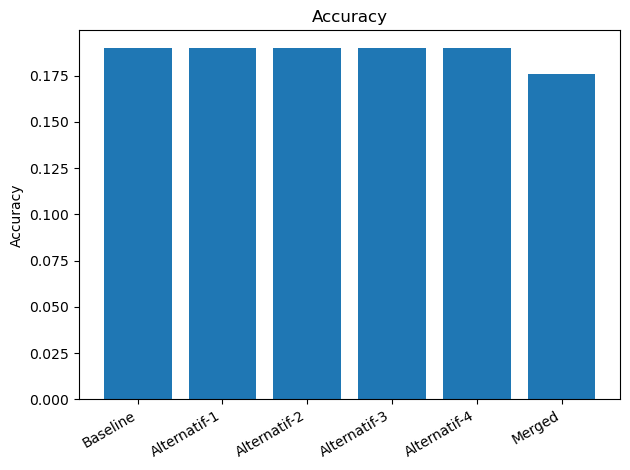

saved: ./results_tables_graphs_manual\01_accuracy.png


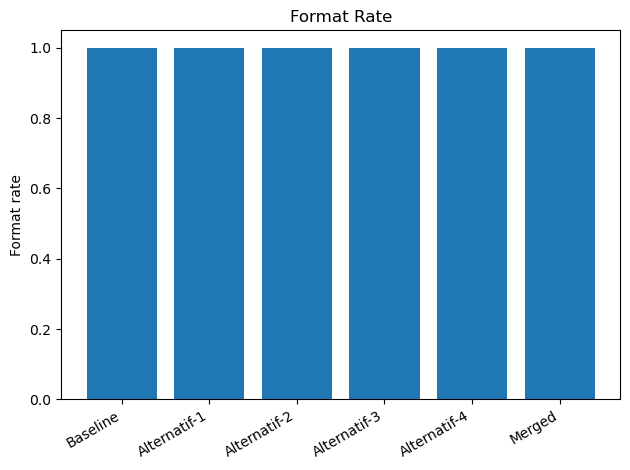

saved: ./results_tables_graphs_manual\02_format_rate.png


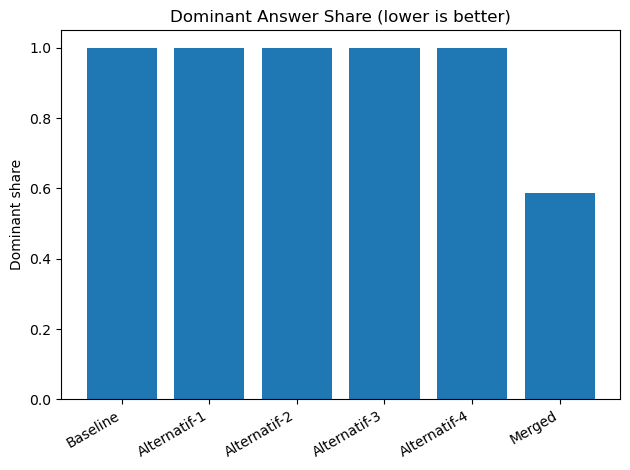

saved: ./results_tables_graphs_manual\03_dominant_share.png


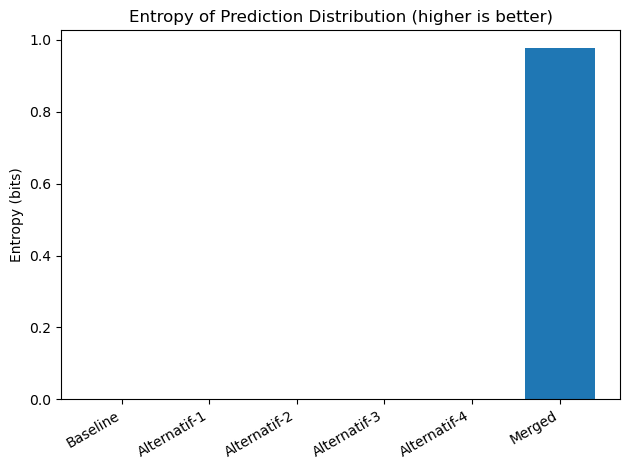

saved: ./results_tables_graphs_manual\04_entropy.png


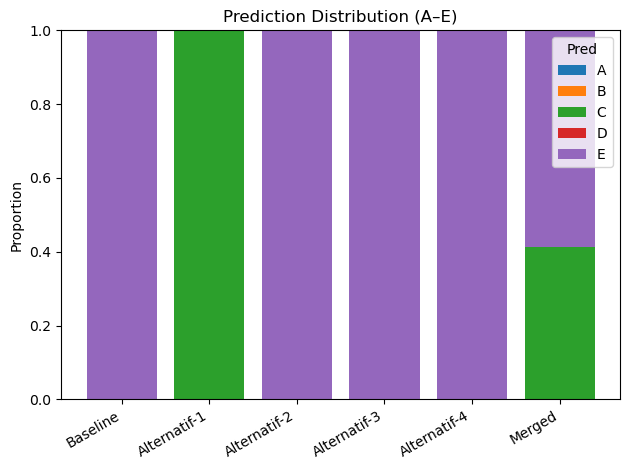

saved: ./results_tables_graphs_manual\05_prediction_distribution.png

DONE. Klasör: C:\Users\emirk\OneDrive\Desktop\Son\results_tables_graphs_manual


In [76]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "./results_tables_graphs_manual"
os.makedirs(OUT_DIR, exist_ok=True)

RESULTS = [
    {
        "Model": "Merged",
        "N": 500,
        "Accuracy": 0.176,
        "Format rate": 1.0,
        "Dist_A": 0,
        "Dist_B": 0,
        "Dist_C": 206,
        "Dist_D": 0,
        "Dist_E": 294,
    },

    {
        "Model": "Baseline",
        "N": 500,
        "Accuracy": 0.19,
        "Format rate": 1.0,
        "Dist_A": 0, "Dist_B": 0, "Dist_C": 0, "Dist_D": 0, "Dist_E": 500,
    },
    

    {
        "Model": "Alternatif-1",
        "N": 500,
        "Accuracy": 0.19,
        "Format rate": 1.0,
        "Dist_A": 0, "Dist_B": 0, "Dist_C": 500, "Dist_D": 0, "Dist_E": 0,
    },

    {
        "Model": "Alternatif-2",
        "N": 500,
        "Accuracy": 0.19,
        "Format rate": 1.0,
        "Dist_A": 0, "Dist_B": 0, "Dist_C": 0, "Dist_D": 0, "Dist_E": 500,
    },

    {
        "Model": "Alternatif-3",
        "N": 500,
        "Accuracy": 0.19,
        "Format rate": 1.0,
        "Dist_A": 0, "Dist_B": 0, "Dist_C": 0, "Dist_D": 0, "Dist_E": 500,
    },

    {
        "Model": "Alternatif-4",
        "N": 500,
        "Accuracy": 0.19,
        "Format rate": 1.0,
        "Dist_A": 0, "Dist_B": 0, "Dist_C": 0, "Dist_D": 0, "Dist_E": 500,
    }
    
]

df = pd.DataFrame(RESULTS)

letters = ["A","B","C","D","E"]
dist_cols = [f"Dist_{L}" for L in letters]

for c in dist_cols:
    if c not in df.columns:
        df[c] = 0

def dominant_share(row):
    n = row["N"]
    m = max(row[c] for c in dist_cols)
    return (m / n) if n else 0.0

def entropy_bits(row):
    n = row["N"]
    if not n:
        return 0.0
    ent = 0.0
    for c in dist_cols:
        p = row[c] / n
        if p > 0:
            ent -= p * np.log2(p)
    return float(ent)

df["Dominant share"] = df.apply(dominant_share, axis=1)
df["Entropy(bits)"] = df.apply(entropy_bits, axis=1)

df = df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

csv_path = os.path.join(OUT_DIR, "model_comparison_manual.csv")
df.to_csv(csv_path, index=False, encoding="utf-8")
print("CSV saved:", csv_path)

display(df)

models = df["Model"].tolist()

def save_bar(values, title, ylabel, filename):
    plt.figure()
    plt.bar(models, values)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    out = os.path.join(OUT_DIR, filename)
    plt.savefig(out, dpi=200)
    plt.show()
    print("saved:", out)

save_bar(df["Accuracy"].values, "Accuracy", "Accuracy", "01_accuracy.png")
save_bar(df["Format rate"].values, "Format Rate", "Format rate", "02_format_rate.png")
save_bar(df["Dominant share"].values, "Dominant Answer Share (lower is better)", "Dominant share", "03_dominant_share.png")
save_bar(df["Entropy(bits)"].values, "Entropy of Prediction Distribution (higher is better)", "Entropy (bits)", "04_entropy.png")

# Stacked distribution plot (A-E oranları)
counts = df[dist_cols].values.astype(float)
row_sums = counts.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
props = counts / row_sums

bottom = np.zeros(len(models))
plt.figure()
for j,L in enumerate(letters):
    plt.bar(models, props[:,j], bottom=bottom, label=L)
    bottom += props[:,j]
plt.xticks(rotation=30, ha="right")
plt.ylabel("Proportion")
plt.title("Prediction Distribution (A–E)")
plt.legend(title="Pred")
plt.tight_layout()
dist_out = os.path.join(OUT_DIR, "05_prediction_distribution.png")
plt.savefig(dist_out, dpi=200)
plt.show()
print("saved:", dist_out)

print("\nDONE. Klasör:", os.path.abspath(OUT_DIR))
